In [1]:
import os,sys
from scipy import io
import scanpy as sc
import scvelo as scv
import cellrank as cr
from cellrank.kernels import CytoTRACEKernel
import anndata as ad
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import collections
import matplotlib
import warnings
from scipy.sparse import csr_matrix, diags
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "DejaVu Sans",   # e.g., "Arial", "Helvetica"
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "svg.fonttype": "none",         # keep editable text in SVG
})




"""plt.rcParams.update(plt.rcParamsDefault)
rc={"axes.labelsize": 16, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "figure.titleweight":"bold", #"font.size":14,
    "figure.figsize":(5.5,4.2), "font.weight":"regular", "legend.fontsize":10,
    'axes.labelpad':8, 'figure.dpi':300}
plt.rcParams.update(**rc)"""


MTpers=[30,30]
if MTpers[0]==MTpers[1]:
    MTper=MTpers[0]
else:
    MTper=str(MTpers[0]) + "_" + str(MTpers[1])
res=.1
res1=int(res*10**(len(str(res))-2))
dataName="Intestine"
sampleNames=["WT-HFD","LOF-HFD"]
sn="/combined"
for i in sampleNames:
  sn=sn+"_"+i
sn=sn+"_"+str(MTper)+"_"+str(res1)+"/"
print(sn)
mainDir = '/yourDataAndCodeFolder/'
dataDir = mainDir+"loomFiles/RNA_Velocity/"+dataName+"/"+sn
plotDir = mainDir+'analysis/SCA_plots/'+dataName+"/"+sn+"/rnaVelocity/"
processedDataDir = mainDir+'analysis/processed_files/'+dataName+"/"+sn+"/rnaVelocity/"

if not os.path.exists(plotDir):
    os.mkdir(plotDir)
    
if not os.path.exists(processedDataDir):
    os.mkdir(processedDataDir)

# path='/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/My Drive/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/mebocost/'
dataNames=["WT-HFD","LOF-HFD"]
dataType='ABC_'
plotMap="umap"
conditionNames="conditions"
cellTypeNames=dataType+'subCellTypes'
cellTypeConditionNames=dataType+'Cond_SCT'
ext='.svg'
os.chdir(dataDir)
!pwd

/combined_WT-HFD_LOF-HFD_30_1/
/Users/krishangupta/Library/CloudStorage/GoogleDrive-krishan.gupta@enders.tch.harvard.edu/My Drive/Desktop/Krishan_Gupta/Hong/loomFiles/RNA_Velocity/Intestine/combined_WT-HFD_LOF-HFD_30_1


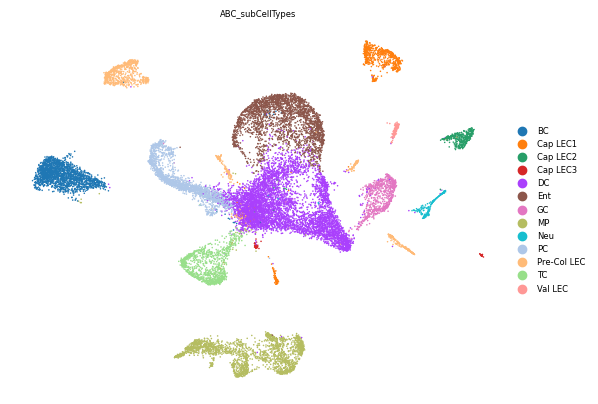

In [2]:
# load sparse matrix:
X = io.mmread(dataDir+"countsF.mtx")

# create anndata object
adata = ad.AnnData(
    X=X.transpose().tocsr()
)

# load cell metadata:
cell_meta = pd.read_csv(dataDir+"metadataF.csv")
cell_meta.index=cell_meta.loc[:,'Unnamed: 0']
del cell_meta['Unnamed: 0']
cell_meta

# load gene names:
with open(dataDir+"gene_namesF.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = [bc[0:len(bc)-4] + '_' + cond for bc,cond in zip(adata.obs['barcode'].tolist(),adata.obs[conditionNames].tolist())]
adata.var.index = gene_names

"""# load dimensional reduction:
pca = pd.read_csv(dataDir+dataType+"pca.csv")
pca.index=pca.loc[:,'Unnamed: 0']
del pca['Unnamed: 0']
pca
adata.obsm['X_pca'] = pca.to_numpy()"""

# set pca and umap
adata.obsm['X_pca'] = np.vstack((adata.obs[dataType+'PCA_1'].to_numpy(), adata.obs[dataType+'PCA_2'].to_numpy())).T
adata.obsm['X_tsne'] = np.vstack((adata.obs[dataType+'TSNE_1'].to_numpy(), adata.obs[dataType+'TSNE_2'].to_numpy())).T
adata.obsm['X_umap'] = np.vstack((adata.obs[dataType+'UMAP_1'].to_numpy(), adata.obs[dataType+'UMAP_2'].to_numpy())).T

# plot a UMAP colored by sampleID to test:
sc.pl.umap(adata, color=[cellTypeNames],size=5, frameon=False, save=cellTypeNames)

# save dataset as anndata format
adata.write(processedDataDir+'my_data.h5ad')

In [3]:
ldata_WT_HFD_0 = scv.read(dataDir+"../../../WT-HFD-Gut/"+'possorted_genome_bam_HJFBZ.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata_WT_HFD_0.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_WT-HFD-Gut' for bc in barcodes]
ldata_WT_HFD_0.obs.index = barcodes
ldata_WT_HFD_0.var_names_make_unique()
print(ldata_WT_HFD_0)

ldata_LOF_HFD_0 = scv.read(dataDir+"../../../LOF-HFD-Gut/"+'possorted_genome_bam_06T03.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata_LOF_HFD_0.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_LOF-HFD-Gut' for bc in barcodes]
ldata_LOF_HFD_0.obs.index = barcodes
ldata_LOF_HFD_0.var_names_make_unique()
print(ldata_LOF_HFD_0)

ldata_WT_HFD_1 = scv.read(dataDir+"../../../06_01_2023/WT-HFD-Gut/"+'possorted_genome_bam_L4PRW.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata_WT_HFD_1.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_WT-HFD-Gut' for bc in barcodes]
ldata_WT_HFD_1.obs.index = barcodes
ldata_WT_HFD_1.var_names_make_unique()
print(ldata_WT_HFD_1)

ldata_LOF_HFD_1 = scv.read(dataDir+"../../../06_01_2023/LOF-HFD-Gut/"+'possorted_genome_bam_LSIIV.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata_LOF_HFD_1.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_LOF-HFD-Gut' for bc in barcodes]
ldata_LOF_HFD_1.obs.index = barcodes
ldata_LOF_HFD_1.var_names_make_unique()
print(ldata_LOF_HFD_1)

/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 6540 × 32285
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 10355 × 32285
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 12900 × 32285
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 13812 × 32285
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
adata = sc.read_h5ad(dataDir+'my_data.h5ad')

WT_HFD_0=adata.obs['conditionsBatched'].index[adata.obs['conditionsBatched']=='WT-HFD_0']
print(WT_HFD_0.shape)
LOF_HFD_0=adata.obs['conditionsBatched'].index[adata.obs['conditionsBatched']=='LOF-HFD_0']
print(LOF_HFD_0.shape)
WT_HFD_1=adata.obs['conditionsBatched'].index[adata.obs['conditionsBatched']=='WT-HFD_1']
print(WT_HFD_1.shape)
LOF_HFD_1=adata.obs['conditionsBatched'].index[adata.obs['conditionsBatched']=='LOF-HFD_1']
print(LOF_HFD_1.shape)

adata_WT_HFD_0=adata[adata.obs['conditionsBatched']=='WT-HFD_0']
print(adata_WT_HFD_0.shape)
adata_LOF_HFD_0=adata[adata.obs['conditionsBatched']=='LOF-HFD_0']
print(adata_LOF_HFD_0.shape)
adata_WT_HFD_1=adata[adata.obs['conditionsBatched']=='WT-HFD_1']
print(adata_WT_HFD_1.shape)
adata_LOF_HFD_1=adata[adata.obs['conditionsBatched']=='LOF-HFD_1']
print(adata_LOF_HFD_1.shape)

adata_WT_HFD_0=scv.utils.merge(adata_WT_HFD_0, ldata_WT_HFD_0)
print(adata_WT_HFD_0.shape)
adata_LOF_HFD_0=scv.utils.merge(adata_LOF_HFD_0, ldata_LOF_HFD_0)
print(adata_LOF_HFD_0.shape)

adata_WT_HFD_1=scv.utils.merge(adata_WT_HFD_1, ldata_WT_HFD_1)
print(adata_WT_HFD_1.shape)
adata_LOF_HFD_1=scv.utils.merge(adata_LOF_HFD_1, ldata_LOF_HFD_1)
print(adata_LOF_HFD_1.shape)

adata = adata_WT_HFD_0.concatenate(adata_LOF_HFD_0,adata_WT_HFD_1,adata_LOF_HFD_1)
print(adata.shape)
adata

# save dataset as anndata format
adata.write(processedDataDir+'my_data_1.h5ad')

(418,)
(762,)
(496,)
(889,)
(418, 20518)
(762, 20518)
(496, 20518)
(889, 20518)
(418, 20506)
(762, 20506)
(496, 20506)
(889, 20506)
(2565, 20506)


/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


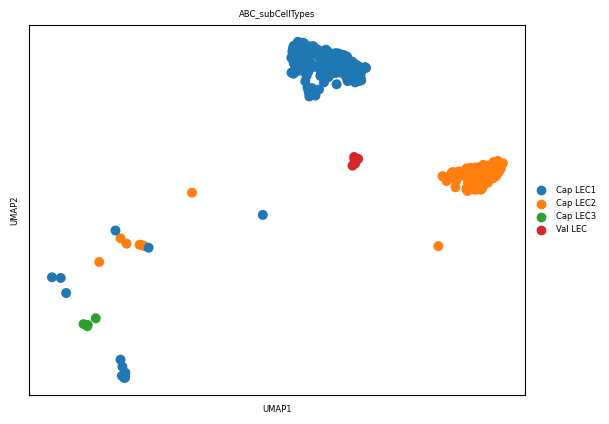

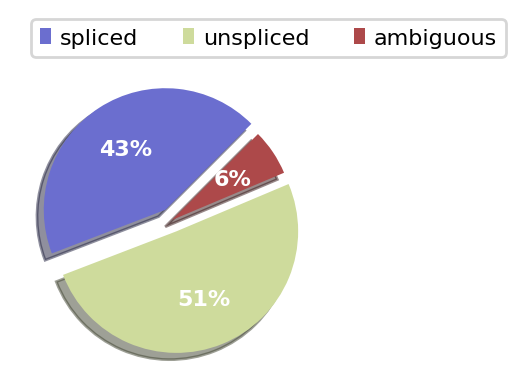

In [5]:
# reload dataset
adata = sc.read_h5ad(processedDataDir+'my_data_1.h5ad')

dataName=dataNames[0]

cellTypes=['Cap LEC1','Cap LEC2','Cap LEC3',"Pre-Col LEC","Val LEC"]
initialState=cellTypes
terminalState=cellTypes

adata = adata[adata.obs[conditionNames].isin([dataName])] # filtering with conditions
adata = adata[adata.obs[cellTypeNames].isin(cellTypes)] # filtering with cellTypes
sc.pl.embedding(adata, basis=plotMap, color=cellTypeNames) # ploting with embeding and cellTypes
scv.settings.verbosity = 3
scv.settings.set_figure_params("scvelo")
cr.settings.verbosity = 2
warnings.simplefilter("ignore", category=UserWarning)
scv.pl.proportions(adata)

# save dataset as anndata format
adata.write(processedDataDir+'my_data_2.h5ad')

# CellRank Meets RNA Velocity

In [ ]:
# reload dataset
adata = sc.read_h5ad(processedDataDir+'my_data_2.h5ad')

scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=True)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

scv.tl.recover_dynamics(adata, n_jobs=8)
scv.tl.velocity(adata, mode="dynamical")

vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()
vk.plot_projection(color=cellTypeNames,legend_loc="right") # ploting with cellTypes
# vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
vk.write_to_adata()
adata.write(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')

Filtered out 18325 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
adata = sc.read_h5ad(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')
vk = cr.kernels.VelocityKernel.from_adata(adata, key="T_fwd")
print(vk)

ck = cr.kernels.ConnectivityKernel(adata)
ck.compute_transition_matrix()
ck.plot_projection(color=cellTypeNames) # ploting with cellTypes

combined_kernel = .8 * vk + .2 * ck
vk.plot_projection(color=cellTypeNames) # ploting with cellTypes
vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
vk.write_to_adata()
adata.write(processedDataDir+"_"+dataType+'_RNA_combined.h5ad')

In [ ]:
import numpy as np
import random

np.random.seed(0)
random.seed(0)
CN=10000

initialState=cellTypes
terminalState=cellTypes
# n_states=9 #10

for dataName in ["WT-HFD","LOF-HFD"]:
    # reload dataset
    adata = sc.read_h5ad(processedDataDir+'my_data_1.h5ad')


    # dataName=dataNames[0]

    adata = adata[adata.obs[conditionNames].isin([dataName])] # filtering with conditions
    adata = adata[adata.obs[cellTypeNames].isin(cellTypes)] # filtering with cellTypes
    adata
    print(adata.shape)
    if adata.n_obs > CN:
        sampled_indices = np.random.RandomState(seed=0).choice(adata.obs_names, size=CN, replace=False)
        adata = adata[sampled_indices]

    # sc.pl.embedding(adata, basis=plotMap, color=cellTypeNames) # ploting with embeding and cellTypes
    scv.settings.verbosity = 3
    scv.settings.set_figure_params("scvelo")
    cr.settings.verbosity = 2
    warnings.simplefilter("ignore", category=UserWarning)
    # scv.pl.proportions(adata)

    # save dataset as anndata format
    adata.write(processedDataDir+'my_data_2.h5ad')

    ########################################################################
    # reload dataset
    adata = sc.read_h5ad(processedDataDir+'my_data_2.h5ad')

    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=True)
    sc.tl.pca(adata)
    sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
    scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

    scv.tl.recover_dynamics(adata, n_jobs=8)
    scv.tl.velocity(adata, mode="dynamical")

    vk = cr.kernels.VelocityKernel(adata)
    vk.compute_transition_matrix()
    # vk.plot_projection(color=cellTypeNames,legend_loc="right") # ploting with cellTypes
    # vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
    vk.write_to_adata()
    adata.write(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')

    ########################################################################
    adata = sc.read_h5ad(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')
    vk = cr.kernels.VelocityKernel.from_adata(adata, key="T_fwd")
    print(vk)

    ck = cr.kernels.ConnectivityKernel(adata)
    ck.compute_transition_matrix()
    ck.plot_projection(color=cellTypeNames) # ploting with cellTypes

    combined_kernel = .8 * vk + .2 * ck
    vk.plot_projection(color=cellTypeNames) # ploting with cellTypes
    # vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
    vk.write_to_adata()
    adata.write(processedDataDir+"_"+dataType+'_RNA_combined.h5ad')

    ########################################################################

    for n_states in range(1, 21, 1): # range(1, 21, 1):
        try:
            print(n_states, dataName)
            adata = sc.read_h5ad(processedDataDir+"_"+dataType+'_RNA_combined.h5ad')
            vk = cr.kernels.VelocityKernel.from_adata(adata, key="T_fwd")
            # print(vk)

            g = cr.estimators.GPCCA(vk)
            # print(g)

            g.fit(cluster_key=cellTypeNames, n_states=[n_states, n_states])  # for HFR [12, 12] # for DKO [4, 3]
            # g.plot_macrostates(which="all", discrete=True, legend_loc="right", s=100)


            g.predict_initial_states(allow_overlap=True)
            # g.plot_macrostates(which="initial", legend_loc="right", s=100)

            terminalState=g.macrostates.values.unique()
            terminalState=[i for i in terminalState if i==i]
            # terminalState=['HC2 Alb hi', 'HC Alb Hnf4a hi', 'HC Hnf4a hi'] # only for WT, but not nesassary to do
            # print(terminalState)


            # g.predict_terminal_states()
            g.set_terminal_states(states=terminalState,allow_overlap=True)
            # g.plot_macrostates(which="terminal", legend_loc="right", s=100)

            # g.plot_macrostates(which="terminal", discrete=False)


            g.compute_fate_probabilities()
            # g.plot_fate_probabilities(same_plot=False)
            # g.plot_coarse_T()


            lineages=terminalState

            """for i in lineages:
                cr.pl.aggregate_fate_probabilities(
                adata,
                mode="violin",
                lineages=i,
                cluster_key=cellTypeNames,
                # clusters=fev_states,
                save=plotDir+"_"+dataType+'_cellrank_Violin.svg',
                figsize=(5, 4),
              dpi=400
            )"""

            all_terminal_sites_prob=pd.DataFrame(g.fate_probabilities)
            cell_index=pd.DataFrame(adata.obs)
            cell_index=cell_index[[cellTypeNames]]
            all_terminal_sites_prob.index=cell_index.index
            df2=pd.concat([all_terminal_sites_prob,cell_index],axis=1)
            terminalState.append(df2.columns[-1])
            df2.columns=terminalState
            ########################################################################
            #######################################################################
            cellTypes=sorted(list(df2[cellTypeNames].unique()))
            df1=df2.copy()
            for ct in cellTypes:
                # print(ct)
                matches = [item for item in df1.columns if ct in item]
                if len(matches)==0:
                    df1[ct]=0
                if len(matches)>1:
                    df1[ct]=0
                    for sct in matches:
                        df1[ct]=df1[ct]+df1[sct]
                    df1 = df1.drop(columns=matches)
            print(df1.columns)

            df=df1.groupby(cellTypeNames).mean().round(3)
            # print(df.sum(axis=1))
            # df.columns=terminalState

            # print(df)

            orderCells=cellTypes
            df=df.loc[orderCells[::-1],orderCells] # terminal state
            df.to_csv(plotDir+dataName+"_"+str(n_states)+"_heatmap.csv", index=False)


            plt.figure(figsize=(12, 6))
            heatmap = sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".3f")

            # Setting the labels
            plt.title('Probabilities')
            plt.xlabel('Terminal State')
            plt.ylabel('Initial State')
            plt.savefig(plotDir+dataName+"_"+str(n_states)+"_heatmap.svg", format="svg")
            plt.show()

            """df_melted = pd.melt(df1, id_vars=terminalState[-1], var_name='Terminal state', value_name='Probability')
            category_order = cellTypes # initial State
            df_melted['Terminal state'] = pd.Categorical(df_melted['Terminal state'], categories=category_order, ordered=True)

            print("\nMelted DataFrame:")
            print(df_melted)

            plt.figure(figsize=(10, 4))  # Set the figure size
            sns.violinplot(x=terminalState[-1], y='Probability', hue='Terminal state', data=df_melted,
                        scale='width',  width=0.8, dodge=True)

            # Add title and labels
            plt.title('Box Plot for Each Column with Hue')
            plt.xlabel('Variable')
            plt.ylabel('Value')
            plt.legend(title='', bbox_to_anchor=(.55, .65), loc='center', ncol=1, frameon=True)
            plt.savefig(plotDir+dataName+"_violinplot.svg", format="pdf")
            # Display the plot
            plt.show()"""
        except Exception as e:
            print(f"Error in iteration {str(n_states)}, {dataName}: {e}")


In [ ]:
import numpy as np
import random

np.random.seed(0)
random.seed(0)
CN=10000

initialState=cellTypes
terminalState=cellTypes
cellTypeNames='ABC_subCellTypes'
# n_states=9 #10

for dataName in ["WT-HFD","LOF-HFD"]:
    adata = sc.read_h5ad(processedDataDir+'my_data_1.h5ad')
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="EC5"]="EC3"
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="EC7"]="EC3"
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="FB4"]="FB7"
    print(adata.obs[cellTypeNames].value_counts())


    # dataName=dataNames[0]

    adata = adata[adata.obs[conditionNames].isin([dataName])] # filtering with conditions
    adata = adata[adata.obs[cellTypeNames].isin(cellTypes)] # filtering with cellTypes
    adata
    print(adata.shape)
    if adata.n_obs > CN:
        sampled_indices = np.random.RandomState(seed=0).choice(adata.obs_names, size=CN, replace=False)
        adata = adata[sampled_indices]

    # sc.pl.embedding(adata, basis=plotMap, color=cellTypeNames) # ploting with embeding and cellTypes
    scv.settings.verbosity = 3
    scv.settings.set_figure_params("scvelo")
    cr.settings.verbosity = 2
    warnings.simplefilter("ignore", category=UserWarning)
    # scv.pl.proportions(adata)

    # save dataset as anndata format
    adata.write(processedDataDir+'my_data_2.h5ad')

    ########################################################################
    adata = sc.read_h5ad(processedDataDir+'my_data_2.h5ad')

    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=True)
    sc.tl.pca(adata)
    sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
    scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

    scv.tl.recover_dynamics(adata, n_jobs=8)
    scv.tl.velocity(adata, mode="dynamical")

    vk = cr.kernels.VelocityKernel(adata)
    vk.compute_transition_matrix()
    vk.plot_projection(color=cellTypeNames,legend_loc="right") # ploting with cellTypes
    # vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
    vk.write_to_adata()
    adata.write(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')
    
    ########################################################################################################
    adata = sc.read_h5ad(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')

    adata.obs['ABC_subCellTypes']
    adata.obs['ABC_subCellTypesU']=[adata.obs['ABC_subCellTypes'][i]+str(i) for i in range(len(adata.obs['ABC_subCellTypes']))]
    df2=pd.DataFrame(adata.obsp['T_fwd'].toarray())
    df2.columns=adata.obs['ABC_subCellTypesU']
    cellTypes=sorted(list(adata.obs['ABC_subCellTypes'].unique()))

    df1=df2.copy()
    for ct in cellTypes:
        # print(ct)
        matches = [item for item in df1.columns if ct in item]
        if len(matches)==0:
            df1[ct]=0
        if len(matches)>1:
            df1[ct]=0
            for sct in matches:
                df1[ct]=df1[ct]+df1[sct]
            df1 = df1.drop(columns=matches)
    print(df1.columns)

    df1['ABC_subCellTypes']=list(adata.obs['ABC_subCellTypes'])
    df=df1.groupby('ABC_subCellTypes').mean().round(3)
    orderCells=sorted(list(adata.obs['ABC_subCellTypes'].unique()))
    df=df.loc[orderCells[::-1],orderCells] # terminal state
    print(df.sum(axis=1))

    plt.figure(figsize=(12, 6))
    heatmap = sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f")

    # Setting the labels
    plt.title('Probabilities')
    plt.xlabel('Terminal State')
    plt.ylabel('Initial State')
    plt.savefig(plotDir+dataName+"_heatmap1.svg", format="svg")
    plt.show()

In [ ]:
import numpy as np
import random

np.random.seed(0)
random.seed(0)
CN=10000

initialState=cellTypes
terminalState=cellTypes
cellTypeNames='ABC_subCellTypes'
# n_states=9 #10

for dataName in ["WT-HFD","LOF-HFD"]:
    adata = sc.read_h5ad(processedDataDir+'my_data_1.h5ad')
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="EC5"]="EC3"
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="EC7"]="EC3"
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="FB4"]="FB7"
    print(adata.obs[cellTypeNames].value_counts())


    # dataName=dataNames[0]

    adata = adata[adata.obs[conditionNames].isin([dataName])] # filtering with conditions
    adata = adata[adata.obs[cellTypeNames].isin(cellTypes)] # filtering with cellTypes
    adata
    print(adata.shape)
    if adata.n_obs > CN:
        sampled_indices = np.random.RandomState(seed=0).choice(adata.obs_names, size=CN, replace=False)
        adata = adata[sampled_indices]

    # sc.pl.embedding(adata, basis=plotMap, color=cellTypeNames) # ploting with embeding and cellTypes
    scv.settings.verbosity = 3
    scv.settings.set_figure_params("scvelo")
    cr.settings.verbosity = 2
    warnings.simplefilter("ignore", category=UserWarning)
    # scv.pl.proportions(adata)

    # save dataset as anndata format
    adata.write(processedDataDir+'my_data_2.h5ad')

    ########################################################################
    adata = sc.read_h5ad(processedDataDir+'my_data_2.h5ad')

    # filter, normalize total counts and log-transform
    sc.pp.filter_genes(adata, min_cells=10)
    scv.pp.normalize_per_cell(adata)
    sc.pp.log1p(adata)

    # hvg annotation
    sc.pp.highly_variable_genes(adata)
    print(f"This detected {adata.var['highly_variable'].sum()} highly variable genes. ")

    adata.layers["spliced"] = adata.X
    adata.layers["unspliced"] = adata.X
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

    ctk = CytoTRACEKernel(adata).compute_cytotrace()
    sc.pl.violin(adata, keys=["ct_pseudotime"], groupby=cellTypeNames, rotation=90) # cellTypeNames
    ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
    ctk.plot_projection(basis="X_umap", color=cellTypeNames, legend_loc="right") # cellTypeNames
    sc.pl.embedding(adata, basis="X_umap", color=cellTypeNames) # cellTypeNames

    ctk.plot_random_walks(
        n_sims=100,
        start_ixs={cellTypeNames: initialState}, # cellTypeNames , InitialState
        basis="X_umap",
        color=cellTypeNames, # cellTypeNames
        legend_loc="right",
        seed=1,
    )

    ctk.write_to_adata()
    adata.write(processedDataDir+"_"+dataType+'_cytoTrace.h5ad')
    cr.logging.print_versions()
    
    ########################################################################################################
    adata = sc.read_h5ad(processedDataDir+"_"+dataType+'_cytoTrace.h5ad')

    adata.obs['ABC_subCellTypes']
    adata.obs['ABC_subCellTypesU']=[adata.obs['ABC_subCellTypes'][i]+str(i) for i in range(len(adata.obs['ABC_subCellTypes']))]
    df2=pd.DataFrame(adata.obsp['T_fwd'].toarray())
    df2.columns=adata.obs['ABC_subCellTypesU']
    cellTypes=sorted(list(adata.obs['ABC_subCellTypes'].unique()))

    df1=df2.copy()
    for ct in cellTypes:
        # print(ct)
        matches = [item for item in df1.columns if ct in item]
        if len(matches)==0:
            df1[ct]=0
        if len(matches)>1:
            df1[ct]=0
            for sct in matches:
                df1[ct]=df1[ct]+df1[sct]
            df1 = df1.drop(columns=matches)
    print(df1.columns)

    df1['ABC_subCellTypes']=list(adata.obs['ABC_subCellTypes'])
    df=df1.groupby('ABC_subCellTypes').mean().round(3)
    orderCells=sorted(list(adata.obs['ABC_subCellTypes'].unique()))
    df=df.loc[orderCells[::-1],orderCells] # terminal state
    print(df.sum(axis=1))

    plt.figure(figsize=(12, 6))
    heatmap = sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f")

    # Setting the labels
    plt.title('Probabilities')
    plt.xlabel('Terminal State')
    plt.ylabel('Initial State')
    plt.savefig(plotDir+dataName+"_heatmap2.svg", format="svg")
    plt.show()

In [ ]:
import numpy as np
import random

np.random.seed(0)
random.seed(0)
CN=10000

"""cellTypes=['Fibroblast cells','Endothelial cells']
initialState=['Fibroblast cells','Endothelial cells']
terminalState=['Fibroblast cells','Endothelial cells']"""

initialState=cellTypes
terminalState=cellTypes
cellTypeNames='ABC_subCellTypes'
# n_states=9 #10

for dataName in ["WT-HFD","LOF-HFD"]:
    # reload dataset
    adata = sc.read_h5ad(processedDataDir+'my_data_1.h5ad')
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="EC5"]="EC3"
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="EC7"]="EC3"
    # adata.obs[cellTypeNames][adata.obs[cellTypeNames]=="FB4"]="FB7"
    print(adata.obs[cellTypeNames].value_counts())


    # dataName=dataNames[0]

    adata = adata[adata.obs[conditionNames].isin([dataName])] # filtering with conditions
    adata = adata[adata.obs[cellTypeNames].isin(cellTypes)] # filtering with cellTypes
    adata
    print(adata.shape)
    if adata.n_obs > CN:
        sampled_indices = np.random.RandomState(seed=0).choice(adata.obs_names, size=CN, replace=False)
        adata = adata[sampled_indices]

    # sc.pl.embedding(adata, basis=plotMap, color=cellTypeNames) # ploting with embeding and cellTypes
    scv.settings.verbosity = 3
    scv.settings.set_figure_params("scvelo")
    cr.settings.verbosity = 2
    warnings.simplefilter("ignore", category=UserWarning)
    # scv.pl.proportions(adata)

    # save dataset as anndata format
    adata.write(processedDataDir+'my_data_2.h5ad')

    ########################################################################
    # reload dataset
    adata = sc.read_h5ad(processedDataDir+'my_data_2.h5ad')
    
    # min_shared_counts=20, n_top_genes=2000
    scv.pp.filter_and_normalize(adata, min_shared_counts=1, n_top_genes=2000, subset_highly_variable=True)
    sc.tl.pca(adata)
    sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
    scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

    scv.tl.recover_dynamics(adata, n_jobs=8)
    scv.tl.velocity(adata, mode="dynamical")

    vk = cr.kernels.VelocityKernel(adata)
    vk.compute_transition_matrix()
    # vk.plot_projection(color=cellTypeNames,legend_loc="right") # ploting with cellTypes
    # vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
    vk.write_to_adata()
    adata.write(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')
    
    ########################################################################
    adata = sc.read_h5ad(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')
    scv.tl.velocity_graph(adata)
    # this is needed due to a current bug - bugfix is coming soon.
    adata.uns['neighbors']['distances'] = adata.obsp['distances']
    adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']
    scv.tl.paga(adata, groups='ABC_subCellTypes')
    df = scv.get_df(adata, 'paga/transitions_confidence', precision=2)
    df.style.background_gradient(cmap='Blues').format('{:.2g}')
    print(df)
    
    cats = adata.obs['ABC_subCellTypes'].cat.categories
    df.columns=cats
    df.index=cats
    print(df)
    df.to_csv(plotDir+dataName+'paga_probabilities.csv')
    scv.pl.paga(adata, basis=plotMap, color=['ABC_subCellTypes'],save=plotDir+dataName+'New.svg', size=50, alpha=.1,min_edge_width=2, node_size_scale=1.5)
    plt.savefig(plotDir+dataName+'direction'+ext)

    plt.figure(figsize=(12, 6))
    heatmap = sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f")

    # Setting the labels
    plt.title('Probabilities')
    plt.xlabel('Initial State')
    plt.ylabel('Terminal State')
    plt.savefig(plotDir+dataName+"31.svg", format="svg")
    plt.show()
    
    ########################################################################
    ########################################################################
    ########################################################################
    adata.write(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')
    
    P = vk.transition_matrix            # csr_matrix (n_cells x n_cells), rows sum ~1
    labels = adata.obs['ABC_subCellTypes']
    cats = list(labels.cat.categories)
    codes = labels.cat.codes.to_numpy()             # 0..K-1
    K, n = len(cats), P.shape[0]

    # 2) Build sparse selectors
    #   - row_sel: sum all source rows per cell type  -> (K x n)
    #   - col_sel: sum all target cols per cell type  -> (n x K)
    row_sel = csr_matrix((np.ones(n), (codes, np.arange(n))), shape=(K, n))
    col_sel = csr_matrix((np.ones(n), (np.arange(n), codes)), shape=(n, K))

    # 3) Average over source cells within each type (not sum), then collapse targets
    src_counts = np.bincount(codes, minlength=K)
    A = row_sel @ P                                     # (K x n) sums over source cells
    A = diags(1.0 / np.where(src_counts > 0, src_counts, 1.0)) @ A   # mean over source

    # 4) Sum targets by type -> K x K
    G = A @ col_sel                                     # group→group strengths

    # 5) Row-normalize so each source type sums to 1
    row_sums = np.asarray(G.sum(axis=1)).ravel()
    G = diags(1.0 / np.where(row_sums > 0, row_sums, 1.0)) @ G

    # 6) Nice labeled DataFrame
    df = pd.DataFrame(G.toarray(), index=cats, columns=cats)  # rows: source type, cols: target type

    plt.figure(figsize=(12, 6))
    heatmap = sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f")

    # Setting the labels
    plt.title('Probabilities')
    plt.xlabel('Terminal State')
    plt.ylabel('Initial State')
    plt.savefig(plotDir+dataName+"_heatmap32.svg", format="svg")
    plt.show()